Loss for the true solution (phi(x) = 3x^2): 15500704.467531

Iteration 1
Optimized xi: [ 1.13988658e+00  4.48026280e-01  1.67252573e+00  2.76460142e-01
  3.97431047e-02 -2.14251129e-09 -6.12331170e-02 -9.45377556e-01]
Threshold for sparsity: 0.167253
Indices with small coefficients: [4 5 6]
Current Loss with sparsity enforcement: 1280838.946516

Iteration 2
Optimized xi: [6.50099548e-02 1.02555262e-01 2.88337284e+00 5.34262211e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.40759669e-07]
Threshold for sparsity: 0.288337
Indices with small coefficients: [0 1 3 4 5 6 7]
Current Loss with sparsity enforcement: 1280741.889810

Iteration 3
Optimized xi: [0.         0.         2.98341003 0.         0.         0.
 0.         0.        ]
Threshold for sparsity: 0.298341
Indices with small coefficients: [0 1 3 4 5 6 7]
Current Loss with sparsity enforcement: 1280747.141121

Iteration 4
Optimized xi: [0.         0.         2.98336527 0.         0.         0.
 0.         0.        ]
Threshold

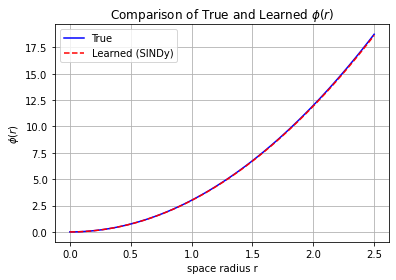

In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.signal import convolve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Read data from CSV
density_df = pd.read_csv('N=2e4.csv')
u = density_df.values

# Adjust input data to match the format for kernel calculation, where nt is the number of time steps and nx is the number of spatial points
x_min, x_max = -4, 4  # Adjust based on the previous KDE range
dx = 0.08            # Grid size for KDE
nx = u.shape[1]      # Get the number of spatial points from the KDE data
x = np.linspace(x_min, x_max, nx)

nt = u.shape[0]      # Get the number of time steps from the KDE data
t_min, t_max = 0, 1
dt = (t_max - t_min) / nt

# Define the phi function
def phi(r):
    return 3 * r**2

# True K_phi(x)
def K_phi(x):
    return 3 * x**2 * np.sign(x)

# Candidate library Θ(x): [1, x, x^2, x^3, e^x, e^-x, sinx, cosx]
def generate_candidate_library(x, degree=3):
    library = []
    # Polynomial terms
    for i in range(degree + 1):
        library.append(x ** i)
        
    # Exponential functions
    library.append(np.exp(x))
    library.append(np.exp(-x))
    # Trigonometric functions
    library.append(np.sin(x))
    library.append(np.cos(x))
    
    return np.vstack(library).T
   
# Calculate Kψ(x) = ψ(|x|) * (x/|x|)
def calculate_K_psi(x, Theta, xi):
    abs_x = np.abs(x)
    Theta_abs = generate_candidate_library(abs_x, degree)
    psi_values = np.dot(Theta_abs, xi)  # ψ(|x|) = Θ(|x|) · ξ
    ratio = np.divide(x, abs_x, out=np.zeros_like(x), where=abs_x != 0)  # Handle x=0 case
    return psi_values * ratio

# Calculate total error
def calculate_total_error(xi, Theta_scaled):
    all_errors = []
    for n in range(1, nt):  # Start from time step 1 since step 0 is the initial condition
        # Calculate time derivative ∂u/∂t
        u_t = (u[n, :] - u[n-1, :]) / dt  
        
        # Calculate second-order spatial derivative ∂²u/∂x²
        u_xx = (np.roll(u[n, :], -1) - 2*u[n, :] + np.roll(u[n, :], 1)) / dx**2
        
        # Calculate Kψ(x)
        K_psi = calculate_K_psi(x, Theta_scaled, xi)  
        
        # Calculate ∂[u(x,t)K_psi(x)]/∂x
        conv_term_1 = convolve(u[n, :], K_psi, mode='same') * dx
        
        u_conv = u[n, :] * conv_term_1
        greadiant_u_conv = (np.roll(u_conv, -1) - np.roll(u_conv, 1)) / (2 * dx)
        
        # Calculate error term
        error = np.abs(u_t - u_xx -  greadiant_u_conv)
        
        # Add error to the total error list
        all_errors.append(error)
        
    # Combine errors from all time steps into a single vector
    return np.hstack(all_errors)

# Initialize xi and other optimization parameters
degree = 3
Theta = generate_candidate_library(x, degree)
scaler = StandardScaler()
Theta_scaled = scaler.fit_transform(Theta) 
n_iterations = 100  
max_iterations = 10

# Initialize xi and mask
initial_xi = np.random.randn(Theta.shape[1])  # Random initialization
lambda_reg = 50  # L1 regularization parameter
mask = np.ones_like(initial_xi, dtype=bool)  # Mask, initially all True

xi = initial_xi.copy()  # Current xi
for iteration in range(max_iterations):
    print(f"\nIteration {iteration + 1}")
    
    # Define the objective function to optimize only unmasked positions
    def objective_function_masked(xi_masked, Theta_scaled, lambda_reg=lambda_reg):
        xi_full = np.zeros_like(xi)
        xi_full[mask] = xi_masked  # Update only unmasked positions
        total_error = calculate_total_error(xi_full, Theta_scaled)
        l1_penalty = lambda_reg * np.sum(np.abs(xi_masked))  # Apply regularization only to unmasked coefficients
        return np.sum(total_error) + l1_penalty

    # Initial value is the current xi at unmasked positions
    xi_masked_initial = xi[mask]

    # Optimize the objective function
    result = minimize(objective_function_masked, xi_masked_initial, args=(Theta_scaled, lambda_reg), method='L-BFGS-B')
    xi_masked_optimized = result.x

    # Update xi
    xi[mask] = xi_masked_optimized

    print("Optimized xi:", xi)

    # Enforce sparsity: Set coefficients smaller than a threshold to zero
    alpha = 0.1  # Set the threshold ratio, e.g., 1%
    threshold = alpha * np.max(np.abs(xi))  # Set threshold based on the maximum value of xi
    small_coef_indices = np.where(np.abs(xi) < threshold)[0]
    print(f"Threshold for sparsity: {threshold:.6f}")
    print("Indices with small coefficients:", small_coef_indices)
    xi[small_coef_indices] = 0

    # Update the mask: Set positions of small coefficients to False, so they are not optimized in the next iteration
    mask[small_coef_indices] = False

    # Check if all coefficients have been masked
    if not np.any(mask):
        print("All coefficients have been masked. Stopping iterations.")
        break

    # Output the current loss value
    current_loss = result.fun
    print(f"Current Loss with sparsity enforcement: {current_loss:.6f}")

print("\nFinal optimized xi:", xi)

# Calculate the final total error
total_error_final = calculate_total_error(xi, Theta_scaled)
final_loss = np.sum(total_error_final**2)
print(f"Final Loss without regularization: {final_loss:.6f}")

'''Plotting section'''
# Learned phi(r) using the optimized xi
def learned_phi(r, xi):
    abs_r = np.abs(r)
    library = generate_candidate_library(abs_r, degree=3)  # Use the generate_candidate_library function
    return np.dot(library, xi)

# Range of spatial radius r
r = np.linspace(0, 2.5, 100)

xi_learned = xi  # Use the optimization result

# Plot the true phi(r) and the learned phi(r)
plt.figure(figsize=(6, 4))

# True phi(r)
plt.plot(r, phi(r), label='True', linestyle='-', color='blue')

# Learned phi(r)
plt.plot(r, learned_phi(r, xi_learned), label='Learned (SINDy)', linestyle='--', color='red')

plt.xlabel('space radius r')
plt.ylabel(r'$\phi(r)$')
plt.legend(loc='best')
plt.grid(True)

plt.title('Comparison of True and Learned $\phi(r)$')
plt.show()